In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sales = pd.read_csv("data/sales_train_evaluation.csv")
calendar = pd.read_csv("data/calendar.csv")

day_cols = [c for c in sales.columns if c.startswith("d_")]

# Top 10 sellers in store CA_1
store = sales[sales["store_id"] == "CA_1"].copy()
store["total_sold"] = store[day_cols].sum(axis=1)
top10 = store.nlargest(10, "total_sold")
print(top10[["item_id", "total_sold"]])

          item_id  total_sold
2314  FOODS_3_090      128855
2810  FOODS_3_586       88846
2476  FOODS_3_252       76055
2344  FOODS_3_120       63107
2937  FOODS_3_714       54617
2811  FOODS_3_587       52356
3029  FOODS_3_808       46094
2023  FOODS_2_197       41312
2304  FOODS_3_080       39673
2779  FOODS_3_555       38446


In [2]:
long = top10.melt(
    id_vars=["id", "item_id"],
    value_vars=day_cols,
    var_name="d",
    value_name="units"
)

# attach real dates and holiday info from the calendar
long = long.merge(calendar[["d", "date", "event_name_1", "snap_CA"]], on="d")
long["date"] = pd.to_datetime(long["date"])
long = long.sort_values(["item_id", "date"]).reset_index(drop=True)

print(long.shape)
long.head()

(19410, 7)


,id,item_id,d,units,date,event_name_1,snap_CA
0,FOODS_2_197_CA_1_evaluation,FOODS_2_197,d_1,38,2011-01-29,NaN,0
1,FOODS_2_197_CA_1_evaluation,FOODS_2_197,d_2,31,2011-01-30,NaN,0
2,FOODS_2_197_CA_1_evaluation,FOODS_2_197,d_3,14,2011-01-31,NaN,0
3,FOODS_2_197_CA_1_evaluation,FOODS_2_197,d_4,29,2011-02-01,NaN,1
4,FOODS_2_197_CA_1_evaluation,FOODS_2_197,d_5,24,2011-02-02,NaN,1


In [3]:
cutoff = long["date"].max() - pd.Timedelta(days=28)
train = long[long["date"] <= cutoff]
test  = long[long["date"] >  cutoff]
print("train days:", train["date"].nunique(), "| test days:", test["date"].nunique())

train days: 1913 | test days: 28


C:\Users\kianz\AppData\Local\Temp\ipykernel_5552\373510557.py:1: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  cutoff = long["date"].max() - pd.Timedelta(days=28)


In [4]:
def seasonal_naive(train_units, horizon=28):
    last_week = train_units[-7:]                # final 7 days of training
    reps = int(np.ceil(horizon / 7))
    return np.tile(last_week, reps)[:horizon]   # repeat it 4 times

# error metric: on average, how many units off are we per day?
def mae(actual, forecast):
    return np.mean(np.abs(np.array(actual) - np.array(forecast)))

results = []
for item in long["item_id"].unique():
    tr = train[train["item_id"] == item]["units"].values
    te = test[test["item_id"] == item]["units"].values
    fc = seasonal_naive(tr)
    results.append({"item_id": item, "naive_mae": mae(te, fc)})

baseline = pd.DataFrame(results)
print(baseline)
print("\nAverage MAE:", baseline["naive_mae"].mean().round(2))

       item_id  naive_mae
0  FOODS_2_197   7.571429
1  FOODS_3_080   4.500000
2  FOODS_3_090  16.785714
3  FOODS_3_120  16.785714
4  FOODS_3_252   9.500000
5  FOODS_3_555   3.678571
6  FOODS_3_586   8.535714
7  FOODS_3_587   7.607143
8  FOODS_3_714   5.964286
9  FOODS_3_808   0.000000

Average MAE: 8.09


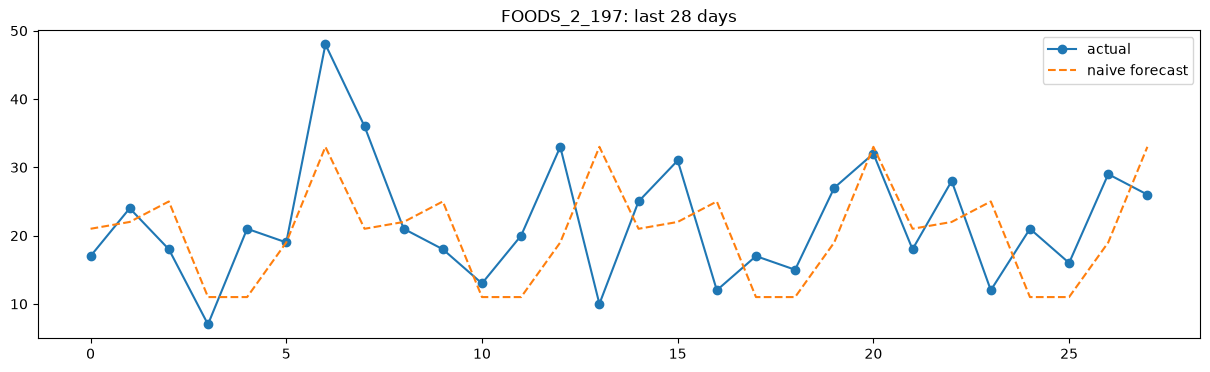

In [5]:
item = long["item_id"].unique()[0]
tr = train[train["item_id"] == item]["units"].values
te = test[test["item_id"] == item]["units"].values

plt.figure(figsize=(15, 4))
plt.plot(range(28), te, label="actual", marker="o")
plt.plot(range(28), seasonal_naive(tr), label="naive forecast", linestyle="--")
plt.title(f"{item}: last 28 days"); plt.legend(); plt.show()

In [6]:
def make_features(df):
    df = df.sort_values(["item_id", "date"]).copy()

    # calendar clues (the patterns YOU found)
    df["dayofweek"] = df["date"].dt.dayofweek        # 0=Mon ... 6=Sun
    df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)
    df["month"] = df["date"].dt.month
    df["is_event"] = df["event_name_1"].notna().astype(int)   # holiday flag

    # memory clues: what happened recently (per product)
    g = df.groupby("item_id")["units"]
    df["lag_7"]  = g.shift(7)     # sales same day last week
    df["lag_14"] = g.shift(14)    # two weeks ago
    df["lag_28"] = g.shift(28)    # four weeks ago
    df["roll_mean_7"]  = g.shift(1).rolling(7).mean().reset_index(0, drop=True)   # avg of last 7 days
    df["roll_mean_28"] = g.shift(1).rolling(28).mean().reset_index(0, drop=True)  # avg of last 28 days

    return df

feat = make_features(long)
feat = feat.dropna(subset=["lag_7", "lag_14", "lag_28", "roll_mean_7", "roll_mean_28"])  # first ~28 days per product have no history, drop them

FEATURES = ["dayofweek", "is_weekend", "month", "is_event", "snap_CA",
            "lag_7", "lag_14", "lag_28", "roll_mean_7", "roll_mean_28"]
feat[FEATURES + ["units"]].head()

,dayofweek,is_weekend,month,is_event,snap_CA,lag_7,lag_14,lag_28,roll_mean_7,roll_mean_28,units
28,5,1,2,0,0,1.0,34.0,38.0,2.428571,17.571429,0
29,6,1,2,0,0,16.0,31.0,31.0,2.285714,16.214286,8
30,0,0,2,0,0,0.0,0.0,14.0,1.142857,15.392857,0
31,1,0,3,0,1,0.0,23.0,29.0,1.142857,14.892857,8
32,2,0,3,0,1,0.0,9.0,24.0,2.285714,14.142857,0


In [7]:
import lightgbm as lgb

train_f = feat[feat["date"] <= cutoff]
test_f  = feat[feat["date"] >  cutoff]

model = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, random_state=42)
model.fit(train_f[FEATURES], train_f["units"])

test_f = test_f.copy()
test_f["pred"] = model.predict(test_f[FEATURES]).clip(min=0)   # can't sell negative units

lgb_mae = test_f.groupby("item_id").apply(
    lambda x: np.mean(np.abs(x["units"] - x["pred"]))
).mean()

print(f"Naive MAE:    8.09")
print(f"LightGBM MAE: {lgb_mae:.2f}")
print(f"Improvement:  {(8.09 - lgb_mae) / 8.09:.1%}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001110 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1092
[LightGBM] [Info] Number of data points in the train set: 18850, number of used features: 10
[LightGBM] [Info] Start training from score 32.564297
Naive MAE:    8.09
LightGBM MAE: 6.10
Improvement:  24.6%


C:\Users\kianz\AppData\Local\Temp\ipykernel_5552\255512373.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  lgb_mae = test_f.groupby("item_id").apply(


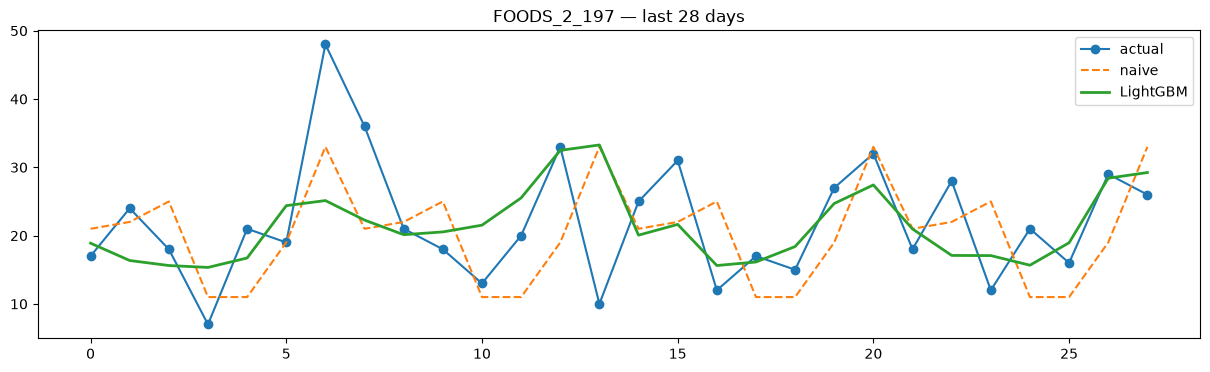

In [8]:
item = test_f["item_id"].value_counts().index[0]   # item with most test rows
one = test_f[test_f["item_id"] == item].sort_values("date")
n = len(one)

tr_item = train[train["item_id"] == item]["units"].values

plt.figure(figsize=(15, 4))
plt.plot(range(n), one["units"].values, label="actual", marker="o")
plt.plot(range(n), seasonal_naive(tr_item, horizon=n), label="naive", linestyle="--")
plt.plot(range(n), one["pred"].values, label="LightGBM", linewidth=2)
plt.title(f"{item} — last {n} days")
plt.legend(); plt.show()

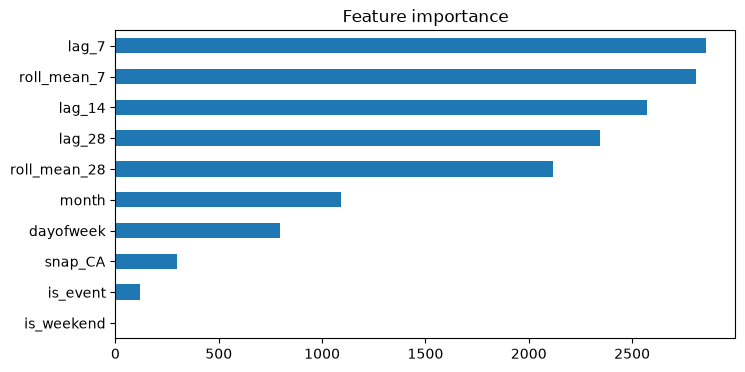

In [9]:
imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
imp.plot(kind="barh", figsize=(8, 4), title="Feature importance")
plt.show()

In [10]:
prices = pd.read_csv("data/sell_prices.csv")

# add the week key to our data
wk = calendar[["d", "wm_yr_wk"]]
long2 = long.merge(wk, on="d")

# we need store_id back (long only kept item_id) — all our items are CA_1
long2["store_id"] = "CA_1"

long2 = long2.merge(
    prices[prices["store_id"] == "CA_1"],
    on=["store_id", "item_id", "wm_yr_wk"],
    how="left"
)
print(long2.shape)          # rows should MATCH long's row count — check this!
print("missing prices:", long2["sell_price"].isna().sum())

(19410, 10)
missing prices: 364


In [11]:
def add_price_features(df):
    df = df.sort_values(["item_id", "date"]).copy()
    g = df.groupby("item_id")["sell_price"]
    df["price_lag_7"] = g.shift(7)
    # price change vs last week: negative = discount happening
    df["price_change"] = (df["sell_price"] - df["price_lag_7"]) / df["price_lag_7"]
    # price vs item's own typical price: below 1 = cheaper than usual
    df["price_rel"] = df["sell_price"] / g.transform("mean")
    return df

long2 = add_price_features(long2)
feat2 = make_features(long2)
feat2 = feat2.dropna(subset=["lag_7", "lag_14", "lag_28", "roll_mean_7", "roll_mean_28", "sell_price"])
print(feat2.shape)

(18794, 22)


In [12]:
FEATURES2 = FEATURES + ["sell_price", "price_change", "price_rel"]

train2 = feat2[feat2["date"] <= cutoff]
test2  = feat2[feat2["date"] >  cutoff]

model2 = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, random_state=42)
model2.fit(train2[FEATURES2], train2["units"])

test2 = test2.copy()
test2["pred"] = model2.predict(test2[FEATURES2]).clip(min=0)

mae2 = test2.groupby("item_id").apply(
    lambda x: np.mean(np.abs(x["units"] - x["pred"]))
).mean()

print(f"Naive MAE:            8.09")
print(f"LightGBM MAE:         6.10")
print(f"LightGBM+price MAE:   {mae2:.2f}")
print(f"Improvement vs naive: {(8.09 - mae2) / 8.09:.1%}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000671 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1163
[LightGBM] [Info] Number of data points in the train set: 18514, number of used features: 13
[LightGBM] [Info] Start training from score 33.155288
Naive MAE:            8.09
LightGBM MAE:         6.10
LightGBM+price MAE:   5.99
Improvement vs naive: 26.0%


C:\Users\kianz\AppData\Local\Temp\ipykernel_5552\835874327.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mae2 = test2.groupby("item_id").apply(


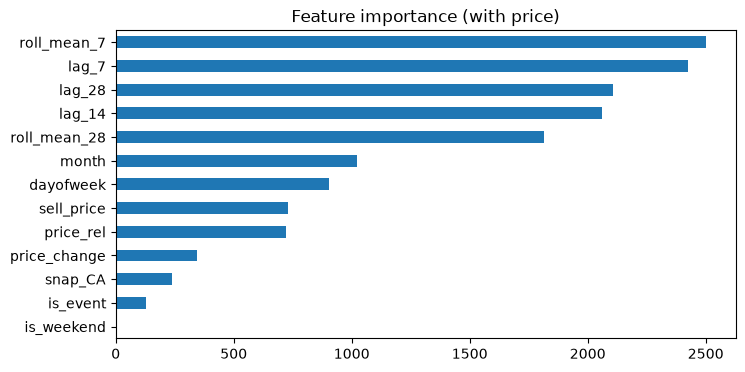

In [13]:
imp = pd.Series(model2.feature_importances_, index=FEATURES2).sort_values()
imp.plot(kind="barh", figsize=(8, 4), title="Feature importance (with price)")
plt.show()

In [14]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from prophet import Prophet
import logging
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)   # silence its chatter

prophet_results = []
for it in long["item_id"].unique():
    df_it = long[long["item_id"] == it][["date", "units"]].rename(
        columns={"date": "ds", "units": "y"}
    )
    tr_p = df_it[df_it["ds"] <= cutoff]
    te_p = df_it[df_it["ds"] >  cutoff]

    m = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
    m.fit(tr_p)

    future = m.make_future_dataframe(periods=len(te_p))
    fc = m.predict(future).tail(len(te_p))["yhat"].clip(lower=0).values

    prophet_results.append({"item_id": it, "prophet_mae": np.mean(np.abs(te_p["y"].values - fc))})

prophet_mae = pd.DataFrame(prophet_results)["prophet_mae"].mean()
print(f"Prophet MAE: {prophet_mae:.2f}")

Importing plotly failed. Interactive plots will not work.
21:38:54 - cmdstanpy - INFO - Chain [1] start processing
21:38:54 - cmdstanpy - INFO - Chain [1] done processing
21:38:55 - cmdstanpy - INFO - Chain [1] start processing
21:38:55 - cmdstanpy - INFO - Chain [1] done processing
21:38:55 - cmdstanpy - INFO - Chain [1] start processing
21:38:55 - cmdstanpy - INFO - Chain [1] done processing
21:38:56 - cmdstanpy - INFO - Chain [1] start processing
21:38:56 - cmdstanpy - INFO - Chain [1] done processing
21:38:56 - cmdstanpy - INFO - Chain [1] start processing
21:38:56 - cmdstanpy - INFO - Chain [1] done processing
21:38:56 - cmdstanpy - INFO - Chain [1] start processing
21:38:56 - cmdstanpy - INFO - Chain [1] done processing
21:38:57 - cmdstanpy - INFO - Chain [1] start processing
21:38:57 - cmdstanpy - INFO - Chain [1] done processing
21:38:57 - cmdstanpy - INFO - Chain [1] start processing
21:38:57 - cmdstanpy - INFO - Chain [1] done processing
21:38:58 - cmdstanpy - INFO - Chain [1

Prophet MAE: 10.68


In [15]:

def recursive_forecast(model_, feat_df, features, cutoff_, horizon=28):
    """Forecast day-by-day, feeding predictions back in as history."""
    hist = feat_df[feat_df["date"] <= cutoff_].copy()      # known truth
    future_days = sorted(feat_df[feat_df["date"] > cutoff_]["date"].unique())[:horizon]
    all_preds = []

    for day in future_days:
        day_rows = feat_df[feat_df["date"] == day].copy()

        # rebuild memory features from hist (truth + our own past predictions)
        for it in day_rows["item_id"].unique():
            past = hist[hist["item_id"] == it].sort_values("date")["units"].values
            mask = day_rows["item_id"] == it
            day_rows.loc[mask, "lag_7"]  = past[-7]  if len(past) >= 7  else np.nan
            day_rows.loc[mask, "lag_14"] = past[-14] if len(past) >= 14 else np.nan
            day_rows.loc[mask, "lag_28"] = past[-28] if len(past) >= 28 else np.nan
            day_rows.loc[mask, "roll_mean_7"]  = past[-7:].mean()
            day_rows.loc[mask, "roll_mean_28"] = past[-28:].mean()

        day_rows["pred"] = model_.predict(day_rows[features]).clip(min=0)

        # append predictions to history as if they were actual sales
        fake = day_rows[["item_id", "date"]].copy()
        fake["units"] = day_rows["pred"].values
        hist = pd.concat([hist[["item_id", "date", "units"]], fake], ignore_index=True)

        all_preds.append(day_rows[["item_id", "date", "pred", "units"]])

    return pd.concat(all_preds, ignore_index=True)

rec = recursive_forecast(model2, feat2, FEATURES2, cutoff)
rec_mae = rec.groupby("item_id").apply(
    lambda x: np.mean(np.abs(x["units"] - x["pred"]))
).mean()
print(f"LightGBM+price (peeking) MAE:  5.99")
print(f"LightGBM+price RECURSIVE MAE:  {rec_mae:.2f}")

LightGBM+price (peeking) MAE:  5.99
LightGBM+price RECURSIVE MAE:  6.95


In [16]:
model2.booster_.save_model("model.txt")
feat2.to_csv("app_data.csv", index=False)

In [17]:
def backtest_rolling(feat_df, features, cutoffs, horizon=28):
    """Rolling-origin evaluation: retrain and recursively forecast at each cutoff."""
    all_folds = []
    for co in cutoffs:
        tr = feat_df[feat_df["date"] <= co]
        m = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, random_state=42)
        m.fit(tr[features], tr["units"])
        preds = recursive_forecast(m, feat_df, features, co, horizon=horizon)
        preds["cutoff"] = co
        all_folds.append(preds)
    return pd.concat(all_folds, ignore_index=True)

last_date = feat2["date"].max()
cutoffs = [last_date - pd.Timedelta(days=d) for d in (84, 56, 28)]   # 3 folds
bt = backtest_rolling(feat2, FEATURES2, cutoffs)

fold_mae = bt.groupby("cutoff").apply(lambda x: np.mean(np.abs(x["units"] - x["pred"])))
print(fold_mae)
print(f"\nMean MAE across folds: {fold_mae.mean():.2f}  (std: {fold_mae.std():.2f})")

for co in cutoffs:
    tr = feat2[feat2["date"] <= co]
    te = bt[bt["cutoff"] == co]
    naive_maes, model_maes = [], []
    for it in te["item_id"].unique():
        tr_units = tr[tr["item_id"] == it].sort_values("date")["units"].values
        te_it = te[te["item_id"] == it].sort_values("date")
        nf = seasonal_naive(tr_units, horizon=len(te_it))
        naive_maes.append(np.mean(np.abs(te_it["units"].values - nf)))
        model_maes.append(np.mean(np.abs(te_it["units"].values - te_it["pred"].values)))
    n, m = np.mean(naive_maes), np.mean(model_maes)
    print(f"{co.date()}  naive: {n:.2f}  model: {m:.2f}  improvement: {(n-m)/n:.1%}")

C:\Users\kianz\AppData\Local\Temp\ipykernel_5552\606374334.py:14: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  cutoffs = [last_date - pd.Timedelta(days=d) for d in (84, 56, 28)]   # 3 folds


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000572 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1160
[LightGBM] [Info] Number of data points in the train set: 17954, number of used features: 13
[LightGBM] [Info] Start training from score 33.380250
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000643 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1161
[LightGBM] [Info] Number of data points in the train set: 18234, number of used features: 13
[LightGBM] [Info] Start training from score 33.256334
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000580 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not eno

In [18]:
def train_quantile_models(train_df, features, quantiles=(0.1, 0.5, 0.9)):
    models = {}
    for q in quantiles:
        m = lgb.LGBMRegressor(objective="quantile", alpha=q,
                              n_estimators=500, learning_rate=0.05, random_state=42)
        m.fit(train_df[features], train_df["units"])
        models[q] = m
    return models

qmodels = train_quantile_models(feat2[feat2["date"] <= cutoff], FEATURES2)

# recursive quantile forecast: roll forward on the MEDIAN, evaluate all three
def recursive_quantile_forecast(qmodels, feat_df, features, cutoff_, horizon=28):
    hist = feat_df[feat_df["date"] <= cutoff_][["item_id", "date", "units"]].copy()
    future_days = sorted(feat_df[feat_df["date"] > cutoff_]["date"].unique())[:horizon]
    out = []
    for day in future_days:
        rows = feat_df[feat_df["date"] == day].copy()
        for it in rows["item_id"].unique():
            past = hist[hist["item_id"] == it].sort_values("date")["units"].values
            mask = rows["item_id"] == it
            rows.loc[mask, "lag_7"], rows.loc[mask, "lag_14"], rows.loc[mask, "lag_28"] = past[-7], past[-14], past[-28]
            rows.loc[mask, "roll_mean_7"], rows.loc[mask, "roll_mean_28"] = past[-7:].mean(), past[-28:].mean()
        for q, m in qmodels.items():
            rows[f"q{int(q*100)}"] = m.predict(rows[features]).clip(min=0)
        fake = rows[["item_id", "date"]].copy(); fake["units"] = rows["q50"].values
        hist = pd.concat([hist, fake], ignore_index=True)
        out.append(rows[["item_id", "date", "units", "q10", "q50", "q90"]])
    return pd.concat(out, ignore_index=True)

qf = recursive_quantile_forecast(qmodels, feat2, FEATURES2, cutoff)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000623 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1163
[LightGBM] [Info] Number of data points in the train set: 18514, number of used features: 13
[LightGBM] [Info] Start training from score 2.000000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000588 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1163
[LightGBM] [Info] Number of data points in the train set: 18514, number of used features: 13
[LightGBM] [Info] Start training from score 27.000000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000546 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enou

In [19]:
coverage = ((qf["units"] >= qf["q10"]) & (qf["units"] <= qf["q90"])).mean()
print(f"Nominal interval: 80%  |  Empirical coverage: {coverage:.1%}")

# pinball loss: the proper score for quantile forecasts
def pinball(actual, pred, q):
    diff = actual - pred
    return np.mean(np.maximum(q * diff, (q - 1) * diff))

for q in (0.1, 0.5, 0.9):
    print(f"Pinball loss @ q={q}: {pinball(qf['units'], qf[f'q{int(q*100)}'], q):.3f}")

# median-model MAE vs your mean model — sanity comparison
q50_mae = qf.groupby("item_id").apply(lambda x: np.mean(np.abs(x["units"] - x["q50"]))).mean()
print(f"\nMedian-model MAE: {q50_mae:.2f}  (mean-model recursive was 6.95)")

Nominal interval: 80%  |  Empirical coverage: 74.3%
Pinball loss @ q=0.1: 1.400
Pinball loss @ q=0.5: 3.108
Pinball loss @ q=0.9: 1.761

Median-model MAE: 6.22  (mean-model recursive was 6.95)


In [20]:
bt.to_csv("backtest.csv", index=False)
qf.to_csv("quantile_forecast.csv", index=False)
print("exported")

exported


In [21]:
for q, m in qmodels.items():
    m.booster_.save_model(f"model_q{int(q*100)}.txt")
print("saved q10, q50, q90")

saved q10, q50, q90
